<a href="https://colab.research.google.com/github/osamamohamaed/Myprojects/blob/main/Roller_Coaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import learning_curve
from sklearn.ensemble import HistGradientBoostingClassifier

##Read the data

In [ ]:
#df = pd.read_csv('/content/safer-parks-accident-dataset.csv')
#df.head()

import kagglehub
import pandas as pd

# Download latest version
dataset_path = kagglehub.dataset_download("stevenlasch/roller-coaster-accidents")

print("Path to dataset files:", dataset_path)

# Read the CSV file into a DataFrame
df = pd.read_csv(f"{dataset_path}/safer-parks-accident-dataset.csv")
df.head()

Using Colab cache for faster access to the 'roller-coaster-accidents' dataset.
Path to dataset files: /kaggle/input/roller-coaster-accidents


,acc_id,acc_date,acc_state,acc_city,fix_port,source,bus_type,industry_sector,device_category,device_type,...,gender,acc_desc,injury_desc,report,category,mechanical,op_error,employee,notes,year
0,1007272,2009-04-05,CA,Anaheim,F,California Division of Occupational Safety and...,Amusement park,amusement ride,cars & track rides,Track ride,...,F,Patron's attorney stated that she had a right ...,Right vertegral artery tear,0,Illness or neurological symptoms,False,False,False,0,2009
1,918972,2009-02-05,FL,Naples,P,Florida Dept. of Agriculture,Carnival or rental,amusement ride,pendulum,Flying carpet ride,...,F,17-yo female was ejected from the ride mid-cyl...,Multiple broken ribs and bruised lung,https://saferparksdata.org/sites/default/files...,Fall: ejection/fall from ride,True,False,False,"This was the third ejection on this ride, unde...",2009
2,919123,2008-11-08,CA,Buena Park,F,California Division of Occupational Safety and...,Amusement park,amusement ride,coaster,Coaster - steel,...,M,Guest injured right hand while riding.,Injured hand. Treated at local hospital.,0,Unknown (not enough info),False,False,False,0,2008
3,919095,2008-11-01,CA,Anaheim,F,California Division of Occupational Safety and...,Amusement park,amusement ride,spinning,Spinning cups/tubs,...,F,"Guest stated when she sat down in the vehicle,...",Nosebleed. Treated at local hospital.,0,Illness or neurological symptoms,False,False,False,0,2008
4,919094,2008-10-29,CA,Anaheim,F,California Division of Occupational Safety and...,Amusement park,amusement ride,spinning,Spinning cups/tubs,...,F,Guest stated she felt lightheaded and experien...,"Dizziness, high blood pressure. Treated at lo...",0,Illness or neurological symptoms,False,False,False,0,2008


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14884 entries, 0 to 14883
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   acc_id                14884 non-null  int64  
 1   acc_date              14884 non-null  object 
 2   acc_state             14884 non-null  object 
 3   acc_city              14884 non-null  object 
 4   fix_port              14884 non-null  object 
 5   source                14884 non-null  object 
 6   bus_type              14884 non-null  object 
 7   industry_sector       14884 non-null  object 
 8   device_category       14884 non-null  object 
 9   device_type           14884 non-null  object 
 10  tradename_or_generic  14884 non-null  object 
 11  manufacturer          14884 non-null  object 
 12  num_injured           14884 non-null  int64  
 13  age_youngest          14884 non-null  float64
 14  gender                14884 non-null  object 
 15  acc_desc           

In [ ]:
df.describe()


,acc_id,num_injured,age_youngest,year
count,1.488400e+04,14884.000000,14884.000000,14884.000000
mean,9.097222e+05,1.081295,16.858976,2001.885783
std,7.476700e+03,2.360132,16.542130,3.481648
min,8.973520e+05,0.000000,0.000000,1986.000000
25%,9.048528e+05,1.000000,4.000000,2000.000000
50%,9.102445e+05,1.000000,12.000000,2002.000000
75%,9.164742e+05,1.000000,27.000000,2005.000000
max,1.009106e+06,99.000000,110.000000,2009.000000


In [ ]:
df.isnull().sum()

,0
acc_id,0
acc_date,0
acc_state,0
acc_city,0
fix_port,0
source,0
bus_type,0
industry_sector,0
device_category,0
device_type,0


In [ ]:
df['injury_desc'] = df['injury_desc'].fillna('Unknown')
df['notes'] = df['notes'].fillna('None')

In [ ]:
df.duplicated().sum()

np.int64(0)

##Exploratory Data Analysis (EDA)

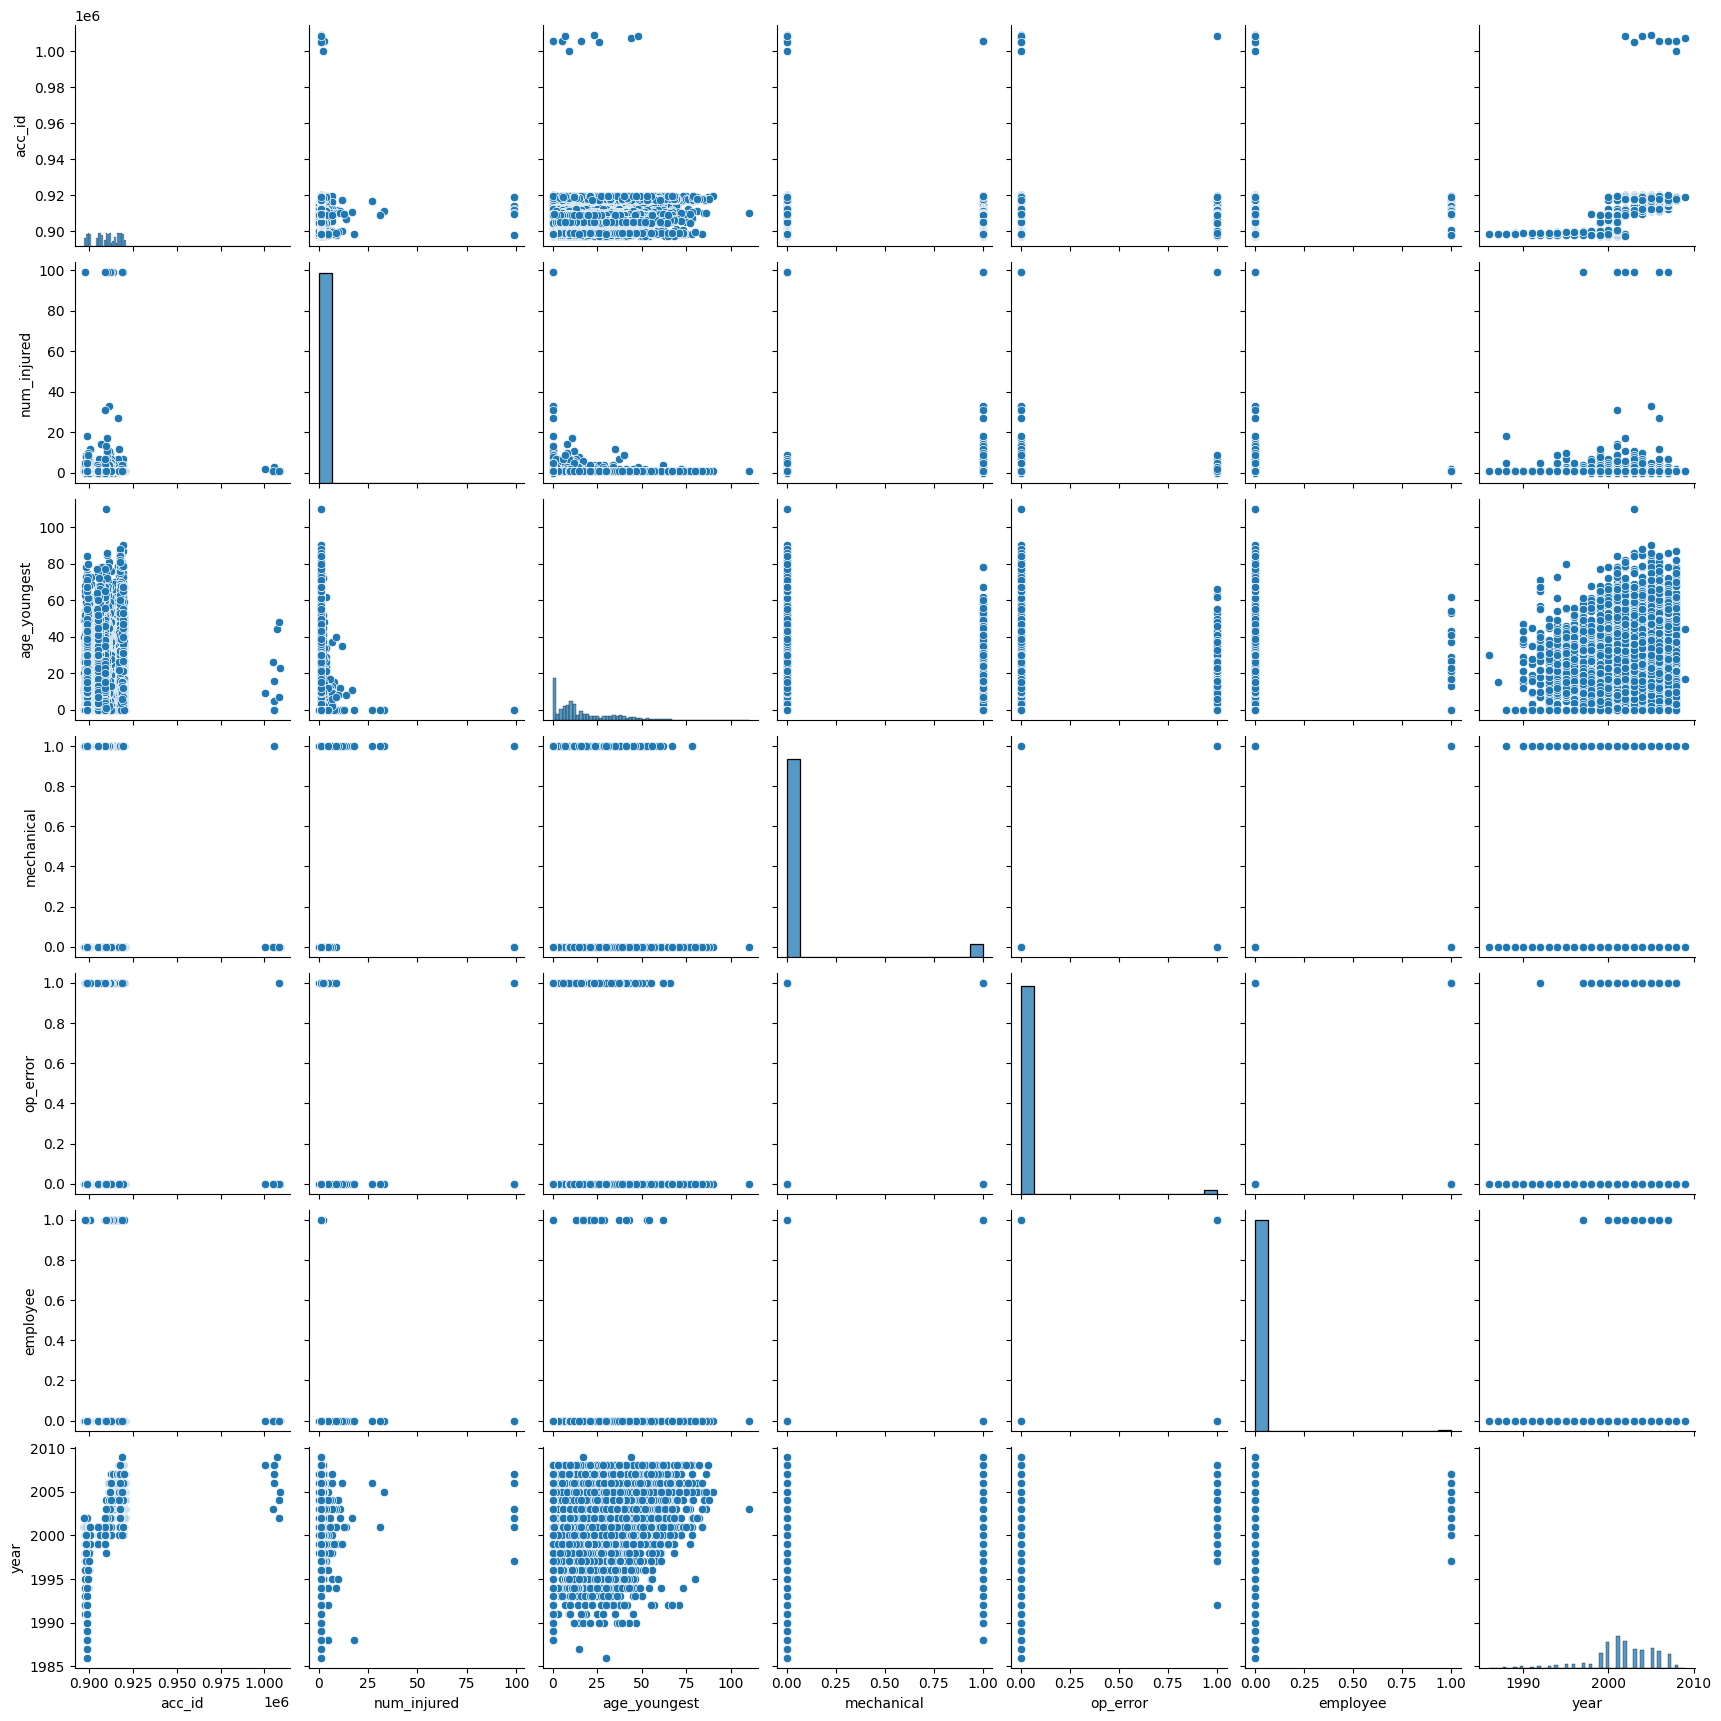

In [ ]:
sns.pairplot(df)

In [ ]:
df['acc_date'] = pd.to_datetime(df['acc_date'], errors='coerce')
df['year'] = df['acc_date'].dt.year
df['month']=df['acc_date'].dt.month_name()
df['day_of_week']=df['acc_date'].dt.day_name()


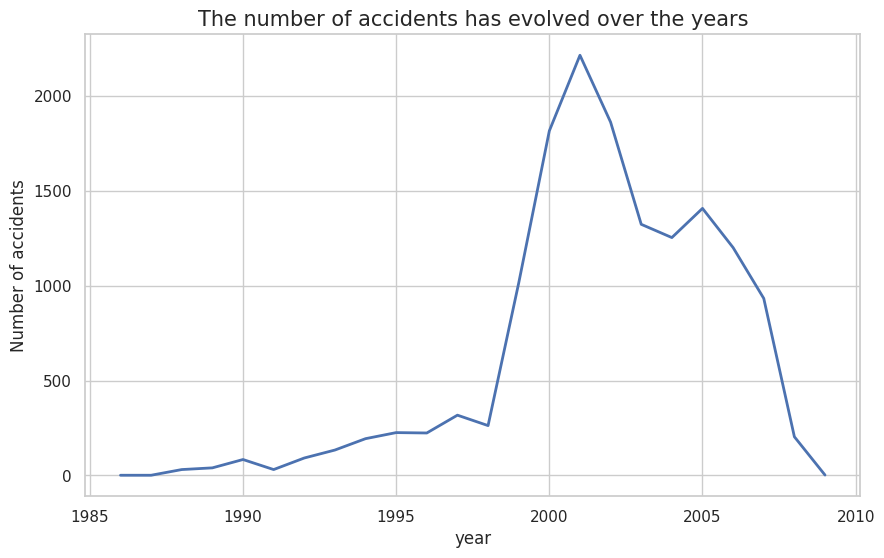

In [ ]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,6))
number_of_years=df['year'].value_counts().sort_index()
sns.lineplot(x=number_of_years.index , y=number_of_years.values ,markers='o',linewidth=2)
plt.title('The number of accidents has evolved over the years', fontsize=15)
plt.xlabel('year', fontsize=12)
plt.ylabel('Number of accidents', fontsize=12)

plt.show()


/tmp/ipykernel_7552/1957766224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')


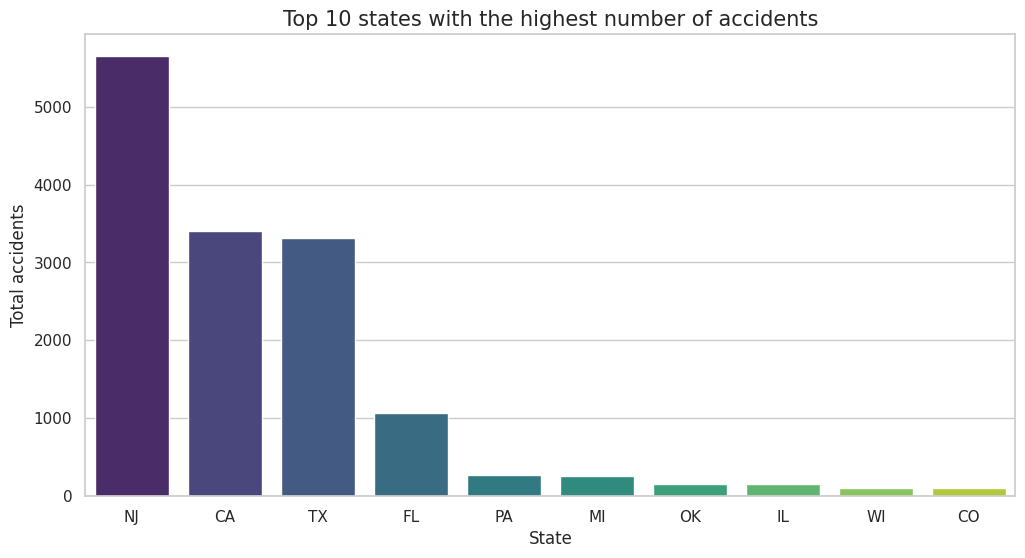

In [ ]:
plt.figure(figsize=(12, 6))
state_counts = df['acc_state'].value_counts().head(10)
sns.barplot(x=state_counts.index, y=state_counts.values, palette='viridis')
plt.title('Top 10 states with the highest number of accidents', fontsize=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total accidents', fontsize=12)

plt.show()

/tmp/ipykernel_7552/2827021318.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_counts.values, y=device_counts.index, palette='rocket')


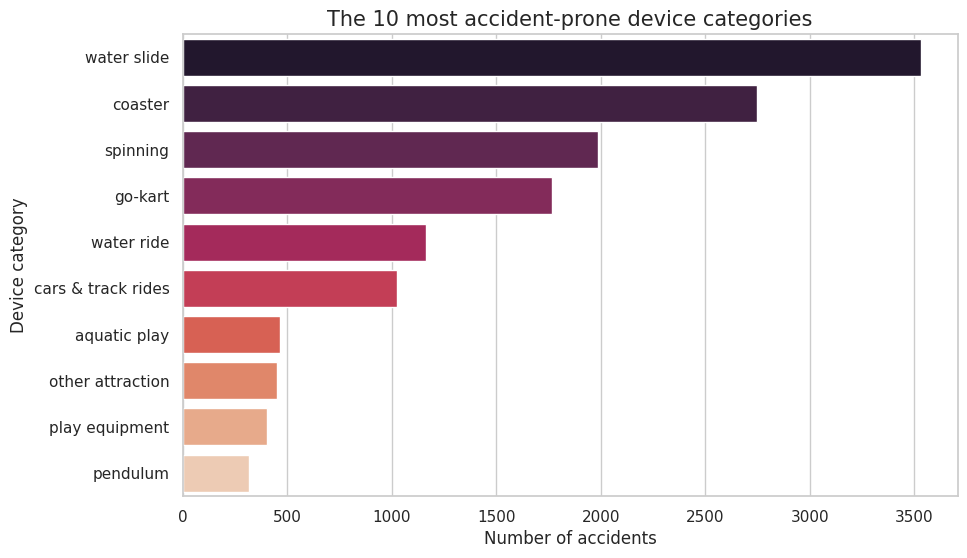

In [ ]:
plt.figure(figsize=(10,6))
device_counts=df['device_category'].value_counts().head(10)
sns.barplot(x=device_counts.values, y=device_counts.index, palette='rocket')
plt.title('The 10 most accident-prone device categories', fontsize=15)
plt.xlabel('Number of accidents', fontsize=12)
plt.ylabel('Device category', fontsize=12)

plt.show()

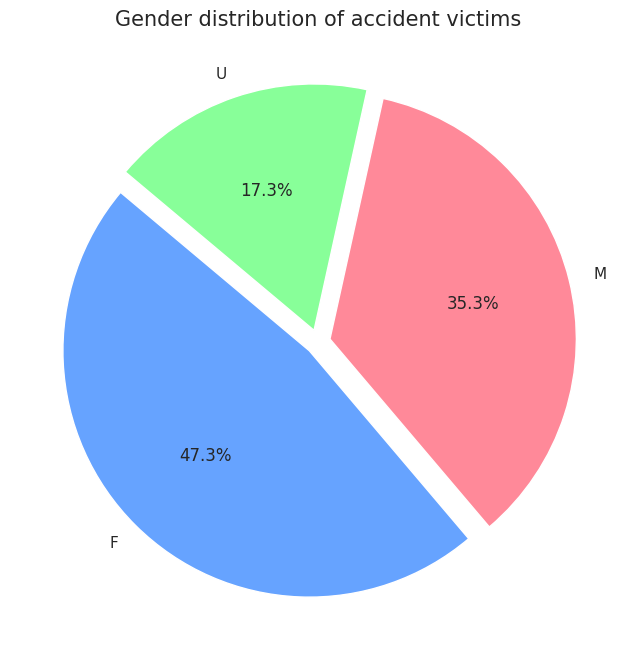

In [ ]:
plt.figure(figsize=(8, 8))
gender_counts=df['gender'].value_counts()
plt.pie(gender_counts,labels=gender_counts.index,autopct='%1.1f%%',colors=['#66a3ff','#ff8999','#88ff99'] , startangle=140,explode=[0.05]*len(gender_counts))


plt.title('Gender distribution of accident victims', fontsize=15)

plt.show()

In [ ]:
# Classifying ages into categories
def bin_age(age):
  if pd.isna(age) or age==0: return 'unknown'
  elif age < 13: return 'child'
  elif age < 20: return 'teen'
  elif age < 60: return 'adult'
  else: return 'senior'

df['age_group'] = df['age_youngest'].apply(bin_age)

In [ ]:
from pandas.core.dtypes.missing import isna
# Accident classifications

def simplify_category(cat):
  if pd.isna(cat): return 'other'
  if 'Fall' in cat: return 'Fall Related'
  elif 'Collision' in cat: return 'Collision'
  elif 'Illness' in cat: return 'Illness'
  elif 'Load/Unload' in cat: return 'Load/Unload'
  else: return 'Technical/Other'

df['broad_category'] = df['category'].apply(simplify_category)


In [ ]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

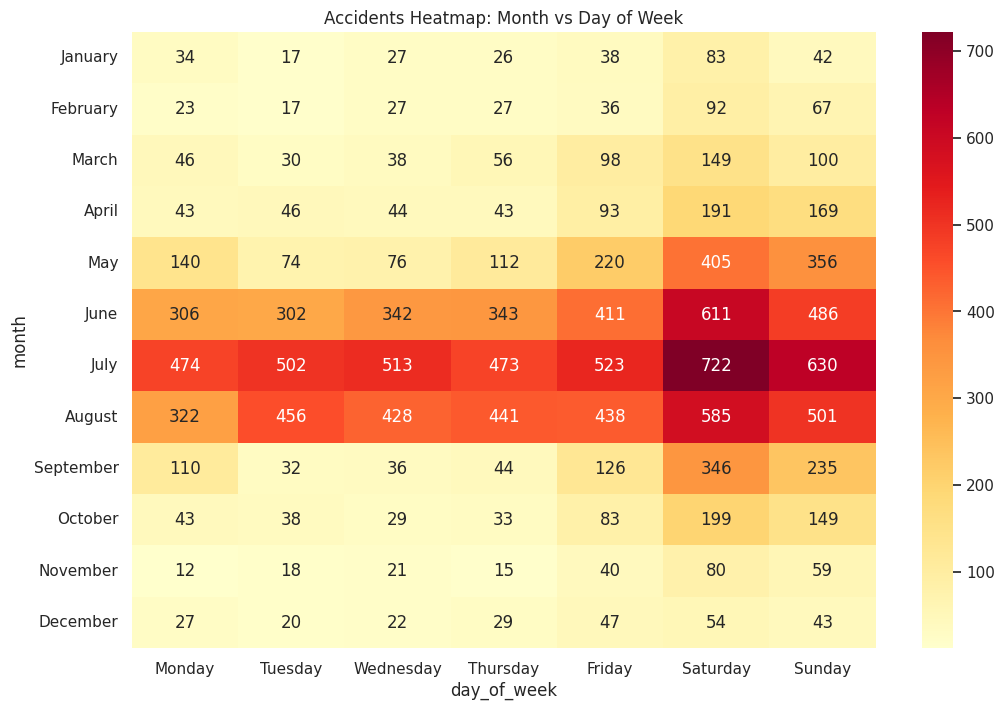

In [ ]:
#Accidents Heatmap
heatmap_data = df.groupby(['month', 'day_of_week']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(index=months_order, columns=days_order)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlOrRd")
plt.title('Accidents Heatmap: Month vs Day of Week')
plt.show()

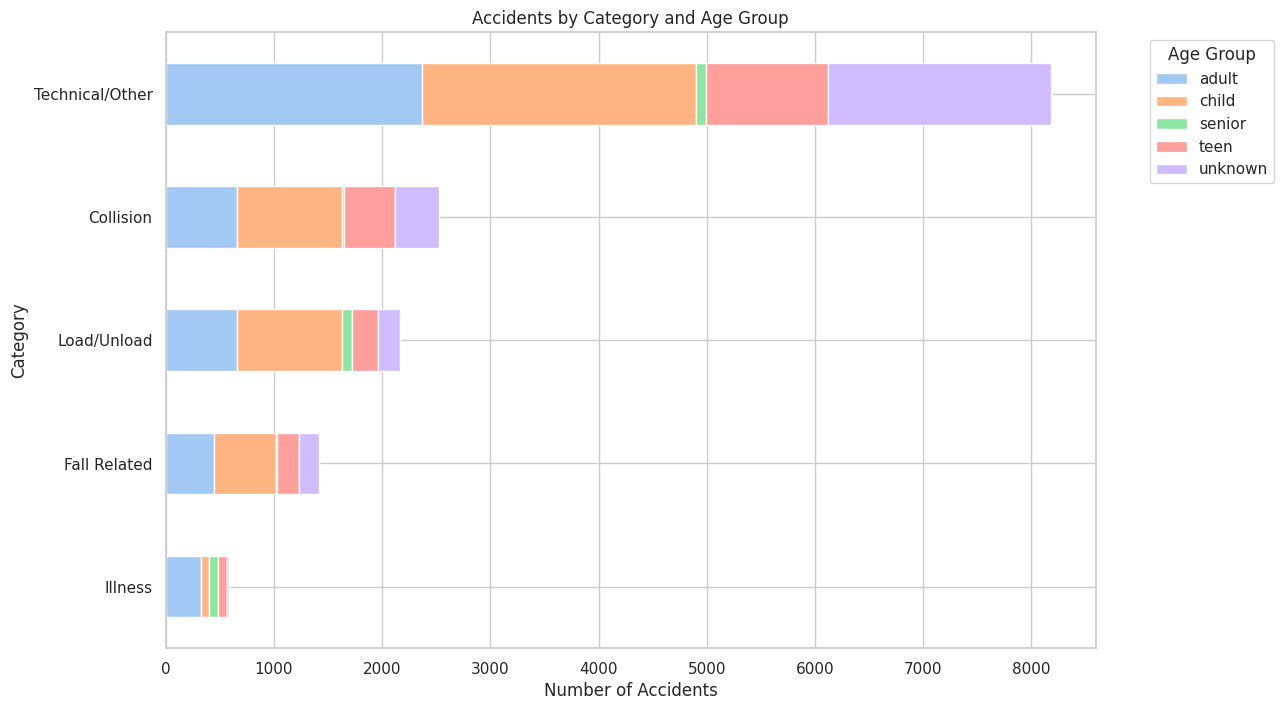

In [ ]:
#Stacked Bar Chart
pivot_tree = df.groupby(['broad_category', 'age_group']).size().unstack(fill_value=0)
pivot_tree['total'] = pivot_tree.sum(axis=1)
pivot_tree = pivot_tree.sort_values('total', ascending=True).drop(columns='total')

pivot_tree.plot(kind='barh', stacked=True, figsize=(12, 8), color=sns.color_palette('pastel'))
plt.title('Accidents by Category and Age Group')
plt.xlabel('Number of Accidents')
plt.ylabel('Category')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##Feature Engineering


In [ ]:
df.head()

,acc_id,acc_date,acc_state,acc_city,fix_port,source,bus_type,industry_sector,device_category,device_type,...,category,mechanical,op_error,employee,notes,year,month,day_of_week,age_group,broad_category
0,1007272,2009-04-05,CA,Anaheim,F,California Division of Occupational Safety and...,Amusement park,amusement ride,cars & track rides,Track ride,...,Illness or neurological symptoms,False,False,False,0,2009,April,Sunday,adult,Illness
1,918972,2009-02-05,FL,Naples,P,Florida Dept. of Agriculture,Carnival or rental,amusement ride,pendulum,Flying carpet ride,...,Fall: ejection/fall from ride,True,False,False,"This was the third ejection on this ride, unde...",2009,February,Thursday,teen,Fall Related
2,919123,2008-11-08,CA,Buena Park,F,California Division of Occupational Safety and...,Amusement park,amusement ride,coaster,Coaster - steel,...,Unknown (not enough info),False,False,False,0,2008,November,Saturday,teen,Technical/Other
3,919095,2008-11-01,CA,Anaheim,F,California Division of Occupational Safety and...,Amusement park,amusement ride,spinning,Spinning cups/tubs,...,Illness or neurological symptoms,False,False,False,0,2008,November,Saturday,adult,Illness
4,919094,2008-10-29,CA,Anaheim,F,California Division of Occupational Safety and...,Amusement park,amusement ride,spinning,Spinning cups/tubs,...,Illness or neurological symptoms,False,False,False,0,2008,October,Wednesday,adult,Illness


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

le = LabelEncoder()
features = ['age_group', 'gender', 'bus_type', 'device_category', 'broad_category']
X = df[features].apply(le.fit_transform)
y = df['mechanical'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42 ,class_weight='balanced')
model.fit(X_train, y_train)
y_pred= model.predict(X_test)


print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Accuracy: 0.8566

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.87      0.92      2793
           1       0.25      0.67      0.37       184

    accuracy                           0.86      2977
   macro avg       0.61      0.77      0.64      2977
weighted avg       0.93      0.86      0.88      2977



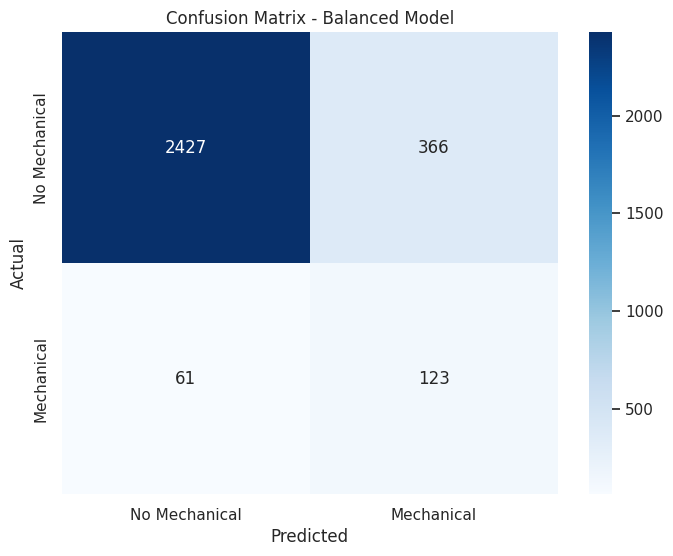

In [ ]:
#Confusion Matrix
cm=confusion_matrix(y_test , y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm , annot=True ,fmt='d',cmap='Blues',xticklabels=['No Mechanical' ,'Mechanical'], yticklabels=['No Mechanical', 'Mechanical'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Balanced Model')
plt.show()

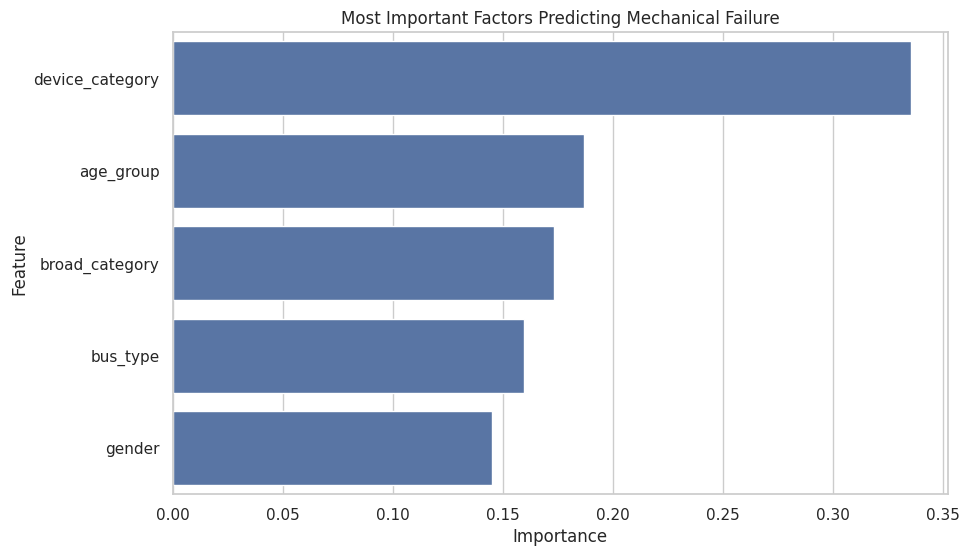

In [ ]:
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df)
plt.title('Most Important Factors Predicting Mechanical Failure')
plt.show()

##Primary Cause


In [ ]:
def define_cause(row):
  if row['mechanical']== True: return 'Mechanical'
  elif row['op_error']==True: return 'Operator Error'
  elif row['employee']==True:return 'Employee Error'
  else: return 'Patron/Other'


df['primary_cause']=df.apply(define_cause , axis=1)


In [ ]:
lencoder=LabelEncoder()
features=['age_group','gender','bus_type','device_category','broad_category','month']
X=df[features].astype(str).apply(lencoder.fit_transform)
y=lencoder.fit_transform(df['primary_cause'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
study_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
study_model.fit(X_train, y_train)

y_pred = study_model.predict(X_test)
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Final Accuracy: 0.8314

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.30      0.43      0.35       187
           2       0.02      0.09      0.04        46
           3       0.95      0.87      0.91      2742

    accuracy                           0.83      2977
   macro avg       0.32      0.35      0.32      2977
weighted avg       0.89      0.83      0.86      2977



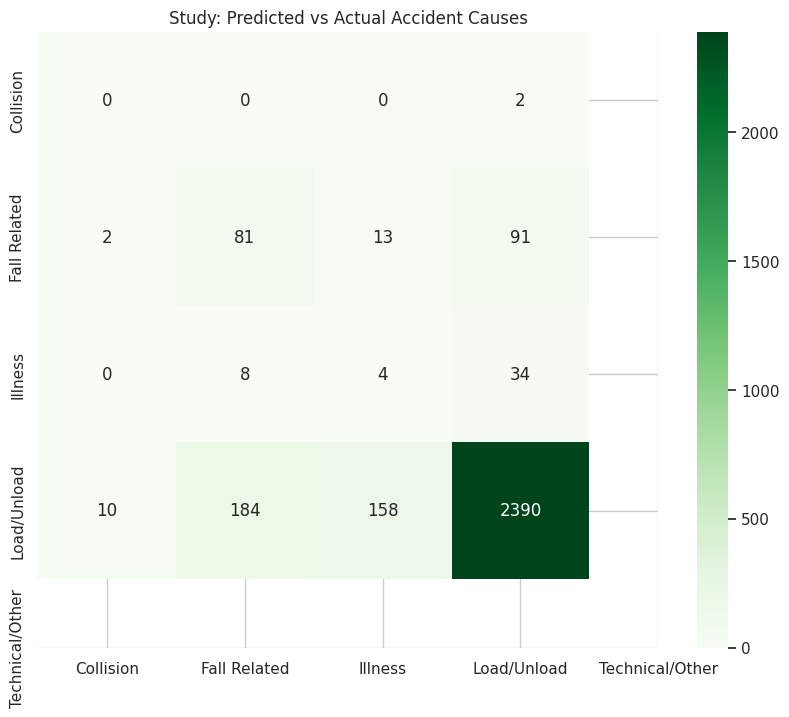

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Study: Predicted vs Actual Accident Causes')
plt.show()

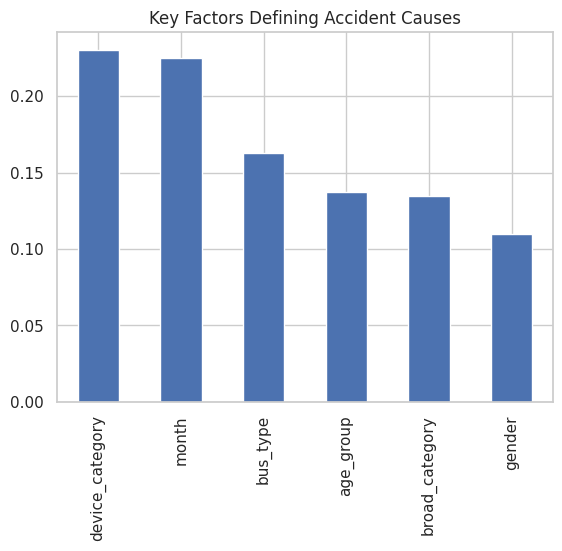

In [ ]:
feat_imp = pd.Series(study_model.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Key Factors Defining Accident Causes')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 1. استخدام نسخة محسنة من Random Forest
# قمنا بزيادة عدد الأشجار (n_estimators) وتحديد العمق (max_depth)
optimized_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)
optimized_rf.fit(X_train, y_train)
print(f"Optimized RF Accuracy: {accuracy_score(y_test, optimized_rf.predict(X_test)):.4f}")

# 2. تجربة خوارزمية HistGradientBoosting (أسرع وأدق في البيانات الضخمة)
hgb_model = HistGradientBoostingClassifier(random_state=42)
hgb_model.fit(X_train, y_train)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, hgb_model.predict(X_test)):.4f}")

Optimized RF Accuracy: 0.9241
Gradient Boosting Accuracy: 0.9224


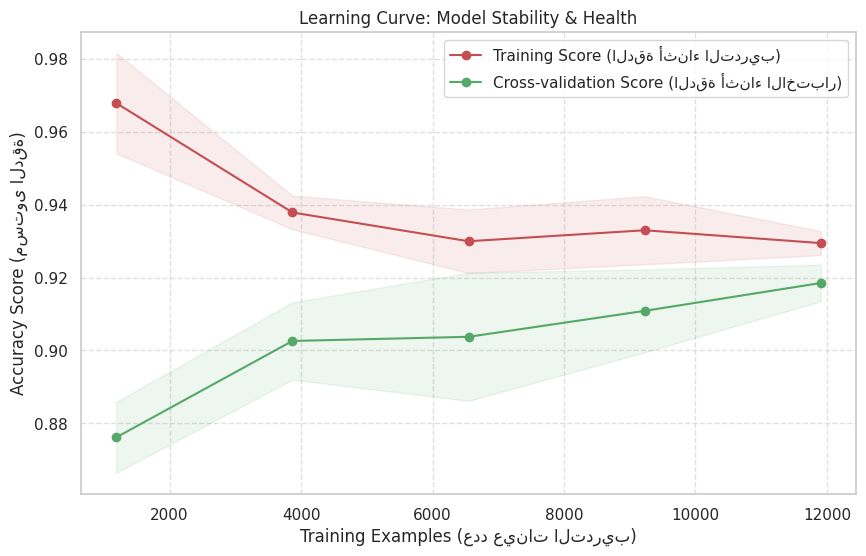

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import HistGradientBoostingClassifier


model = HistGradientBoostingClassifier(random_state=42)


train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score (الدقة أثناء التدريب)")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation Score (الدقة أثناء الاختبار)")


plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve: Model Stability & Health")
plt.xlabel("Training Examples (عدد عينات التدريب)")
plt.ylabel("Accuracy Score (مستوى الدقة)")
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold


lencoder=LabelEncoder()
features=['age_group','gender','bus_type','device_category','broad_category','month']
X=df[features].astype(str).apply(lencoder.fit_transform)
y=pd.Series(lencoder.fit_transform(df['primary_cause']))

X_temp, X_predict, y_temp, y_predict = train_test_split(X, y, test_size=0.10, random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.22, random_state=42)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")
print(f"Prediction set size: {len(X_predict)}")


for fold, (train_index, val_index) in enumerate(kf.split(X_train)):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]


    print(f"Fold {fold+1}: Training on {len(X_fold_train)} samples, Validating on {len(X_fold_val)}")

Training set size: 10448
Testing set size: 2947
Prediction set size: 1489
Fold 1: Training on 8955 samples, Validating on 1493
Fold 2: Training on 8955 samples, Validating on 1493
Fold 3: Training on 8955 samples, Validating on 1493
Fold 4: Training on 8955 samples, Validating on 1493
Fold 5: Training on 8956 samples, Validating on 1492
Fold 6: Training on 8956 samples, Validating on 1492
Fold 7: Training on 8956 samples, Validating on 1492


In [ ]:
!pip install optuna
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


def objective(trial):

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)


    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )


    kf = KFold(n_splits=7, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy').mean()

    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)


print(f"Best Accuracy: {study.best_value}")
print(f"Best Parameters: {study.best_params}")


best_model = RandomForestClassifier(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.3 MB/s eta 0:00:00


[I 2026-04-19 17:00:25,354] A new study created in memory with name: no-name-8bcea5ee-5f0f-4e13-9873-226d3bdd01c5
[I 2026-04-19 17:00:31,180] Trial 0 finished with value: 0.9206544879551529 and parameters: {'n_estimators': 262, 'max_depth': 3, 'min_samples_split': 3}. Best is trial 0 with value: 0.9206544879551529.
[I 2026-04-19 17:00:38,043] Trial 1 finished with value: 0.924005245466973 and parameters: {'n_estimators': 116, 'max_depth': 17, 'min_samples_split': 5}. Best is trial 1 with value: 0.924005245466973.
[I 2026-04-19 17:00:45,810] Trial 2 finished with value: 0.922186596302982 and parameters: {'n_estimators': 199, 'max_depth': 11, 'min_samples_split': 2}. Best is trial 1 with value: 0.924005245466973.
[I 2026-04-19 17:00:54,888] Trial 3 finished with value: 0.9248660222875911 and parameters: {'n_estimators': 253, 'max_depth': 7, 'min_samples_split': 4}. Best is trial 3 with value: 0.9248660222875911.
[I 2026-04-19 17:01:02,878] Trial 4 finished with value: 0.9174012748885837 

Best Accuracy: 0.9259190662001634
Best Parameters: {'n_estimators': 214, 'max_depth': 10, 'min_samples_split': 3}


RandomForestClassifier(max_depth=10, min_samples_split=3, n_estimators=214,
                       random_state=42)